# Manejo de Datos faltantes con Python

Pandas toma prestado todas las capacidades de selección de Numpy y añade una serie de métodos para manejar valore faltantes

In [1]:
import numpy as np
import pandas as pd

Cuatro pasos fundamentales a la limpieza de datos
- Encontrar los datos faltantes (si hay una categoria que esta faltando, hay un precio que esta faltando o un string que esta faltando)
- Arreglar el dataset del cual estan faltando los datos puede ser muy facil o muy complejo. Por ejemplo
    - Si el dato no es muy importante
        - Se puede dar de baja el registro del cual falta el dato
        - Se puede llenar el dato faltante sacando el promedio de los demas datos
    - Si el dato es importante
        - Por ejemplo si es que falta un número telefonico
        - En ese caso habra que llamar a desarrollador del ETL
- Qué pasa cuando tratamos con valores invalidos, por ejemplo:
    - Una columna que es de precios, pero tiene valores en string
    - Una columna que es de edad del cliente y hay un valor de 170 (a esto se llama problema de dominio)

La forma en que Pandas trabaja con valores faltantes son cuatro funciones que son sinonimas

In [2]:
pd.isnull(np.nan)

True

In [3]:
pd.isnull(None)

True

In [4]:
pd.isna(np.nan)

True

In [5]:
pd.isna(None)

True

Los opuestos tambien existen:

In [6]:
pd.notnull(None)

False

In [7]:
pd.notnull(np.nan)

False

In [8]:
pd.notnull(3)

True

Estas funciones tambien trabajan con ***Series*** y ***DataFrames***

In [9]:
pd.isnull(pd.Series([1, np.nan, 7]))

0    False
1     True
2    False
dtype: bool

In [10]:
pd.notnull(pd.Series([1, np.nan, 7]))

0     True
1    False
2     True
dtype: bool

In [11]:
pd.isnull(pd.DataFrame({
    'Columna A': [1, np.nan, 7],
    'Columna B': [np.nan, 2, 3],
    'Columna C': [np.nan, 2, np.nan]
}))

,Columna A,Columna B,Columna C
0,False,True,True
1,True,False,False
2,False,False,True


## Filtrando datos faltantes

Como vimos en numpy, podemos combinar selección booleana + **pd.isnull** para filtrar esos valores *nan* y *nulos*

In [12]:
s = pd.Series([1, 2, 3, np.nan, np.nan, 4])

In [13]:
pd.notnull(s)

0     True
1     True
2     True
3    False
4    False
5     True
dtype: bool

In [14]:
pd.notnull(s).sum() # Devuelve la cantidad de datos no nulos

np.int64(4)

In [15]:
pd.isnull(s).sum() # Caso contrario devuelve la cantidad de datos nulos

np.int64(2)

In [16]:
s[pd.notnull(s)] # Devuelve los valores que no son nulos

0    1.0
1    2.0
2    3.0
5    4.0
dtype: float64

Ambos **notnull** e **isnull** trabajan con *Series* y *DataFrames* asi que lo podemos utilizar de la siguiente manera:

In [17]:
s.isnull()

0    False
1    False
2    False
3     True
4     True
5    False
dtype: bool

In [18]:
s.notnull()

0     True
1     True
2     True
3    False
4    False
5     True
dtype: bool

In [19]:
s[s.notnull()]

0    1.0
1    2.0
2    3.0
5    4.0
dtype: float64

In [20]:
s

0    1.0
1    2.0
2    3.0
3    NaN
4    NaN
5    4.0
dtype: float64

## Dar de baja valores nulos

In [21]:
s.dropna() # Es un método que se utiliza para eliminar valores faltantes de un DataFrame o Serie 
#(tomar en cuenta que esta función no modifica la serie)

0    1.0
1    2.0
2    3.0
5    4.0
dtype: float64

In [22]:
s

0    1.0
1    2.0
2    3.0
3    NaN
4    NaN
5    4.0
dtype: float64

Todo lo mencionado anteriormente tambien funciona con *DataFrames*

In [24]:
df = pd.DataFrame({
    'Column A': [1, np.nan, 30, np.nan],
    'Column B': [1, 8, 31, np.nan],
    'Column C': [np.nan, 9, 32, 100],
    'Column D': [5, 8, 34, 110],
})

In [25]:
df

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34
3,NaN,NaN,100.0,110


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Column A  2 non-null      float64
 1   Column B  3 non-null      float64
 2   Column C  3 non-null      float64
 3   Column D  4 non-null      int64  
dtypes: float64(3), int64(1)
memory usage: 260.0 bytes


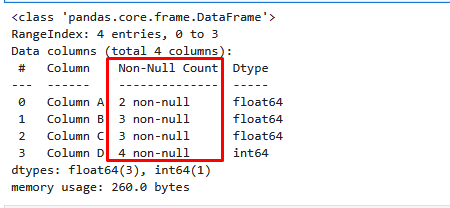

En el recuadro rojo muestro el número de valor que están con *nulo*

In [28]:
df.isnull().sum()

Column A    2
Column B    1
Column C    1
Column D    0
dtype: int64

In [30]:
df.dropna() # Elimina las filas que tengan por lo menos un valor nulo

,Column A,Column B,Column C,Column D
2,30.0,31.0,32.0,34


In [31]:
df.dropna(axis = 1) # Elimina las columnas que tengan por lo menos un valor nulo

,Column D
0,5
1,8
2,34
3,110


In [32]:
df.dropna(how = 'all') # Elimina si todos son nulos

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34
3,NaN,NaN,100.0,110


In [33]:
df.dropna(axis = 1, how = 'all') # Elimina si todos son nulos

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34
3,NaN,NaN,100.0,110


In [36]:
df.dropna(axis = 0, how = 'any') # Comportamiento por defecto

,Column A,Column B,Column C,Column D
2,30.0,31.0,32.0,34


Tambien se puede usar **tresh** para indicar threshold (un número mínimo) de valore no nulos para que la fila o la columna se mantengan

In [37]:
df

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34
3,NaN,NaN,100.0,110


In [38]:
df.dropna(thresh = 3)

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34


## Llenando valore nulos

Algunas veces en vez de eliminar los valores nulos, nosotros podriamos reemplasarlos con otros valores. Algunas veces un **nan** se puede reemplazar con un **0**, otras veces se podra reemplazar con la media y algunas otras veces lo podras reemplazar con algun valor cercano. Todo depende del contexto, te mostraremos algunos mecanismos que puedas aplicar en tus propios problemas

In [39]:
s

0    1.0
1    2.0
2    3.0
3    NaN
4    NaN
5    4.0
dtype: float64

### Llenar valores nulos con valores arbitrarios

In [44]:
s.fillna(0) # En este ejemplo llenaremos los valores faltantes con un valor en particular 0

0    1.0
1    2.0
2    3.0
3    0.0
4    0.0
5    4.0
dtype: float64

In [46]:
s.fillna(s.mean()) # Acá se completaran los datos faltantes con el promedio

0    1.0
1    2.0
2    3.0
3    2.5
4    2.5
5    4.0
dtype: float64

### Llenar valores nulos con valores contiguos o cercanos

**Método ffill** o relleno hacia adelante. Rellena los valores NaN usando el último valor valido anterior

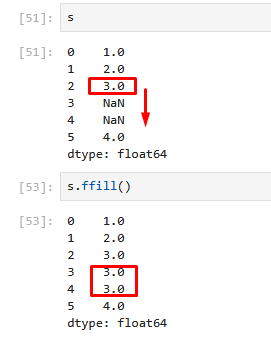

In [56]:
s

0    1.0
1    2.0
2    3.0
3    NaN
4    NaN
5    4.0
dtype: float64

In [57]:
s.ffill()

0    1.0
1    2.0
2    3.0
3    3.0
4    3.0
5    4.0
dtype: float64

**Método bfill** o relleno hacia atras. Rellena los valores NaN usando el siguiente valor valido que aparece abajo

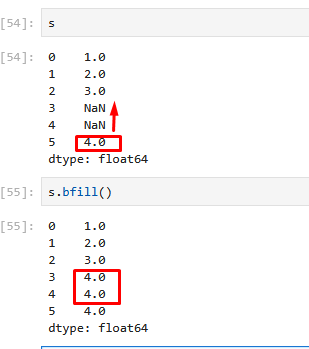

In [58]:
s

0    1.0
1    2.0
2    3.0
3    NaN
4    NaN
5    4.0
dtype: float64

In [59]:
s.bfill()

0    1.0
1    2.0
2    3.0
3    4.0
4    4.0
5    4.0
dtype: float64

## Llenando valores nulos en un DataFrame

In [60]:
df

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34
3,NaN,NaN,100.0,110


In [61]:
df.fillna({'Column A': 0, 'Column B': 99, 'Column C': df['Column C'].mean()})

,Column A,Column B,Column C,Column D
0,1.0,1.0,47.0,5
1,0.0,8.0,9.0,8
2,30.0,31.0,32.0,34
3,0.0,99.0,100.0,110


In [65]:
df

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34
3,NaN,NaN,100.0,110


In [62]:
df.ffill(axis = 0) # Columnas

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,1.0,8.0,9.0,8
2,30.0,31.0,32.0,34
3,30.0,31.0,100.0,110


In [64]:
df

,Column A,Column B,Column C,Column D
0,1.0,1.0,NaN,5
1,NaN,8.0,9.0,8
2,30.0,31.0,32.0,34
3,NaN,NaN,100.0,110


In [66]:
df.ffill(axis = 1) # Filas

,Column A,Column B,Column C,Column D
0,1.0,1.0,1.0,5.0
1,NaN,8.0,9.0,8.0
2,30.0,31.0,32.0,34.0
3,NaN,NaN,100.0,110.0


## Limpiando valores no nulos

En el siguiente DataFrame no tiene valores faltantes, pero claramente el valor 290 parace no ser una edad valida y D y ? no corresponden con ninguna categoria de sexo conocida

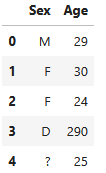

In [90]:
df = pd.DataFrame({
    'Sex': ['M', 'F', 'F', 'D', '?'],
    'Age': [29, 30, 24, 290, 25]
})

In [70]:
df

,Sex,Age
0,M,29
1,F,30
2,F,24
3,D,290
4,?,25


**Función Unique:** Devuelve valores únicos sin repetir que existen en la columna Sex

In [71]:
df['Sex'].unique()

array(['M', 'F', 'D', '?'], dtype=object)

In [74]:
df['Sex'].value_counts()

Sex
F    2
M    1
D    1
?    1
Name: count, dtype: int64

Una vez identificados los valores fuera de lugar, podemos usar los métodos **replace**

In [80]:
df

,Sex,Age
0,M,29
1,F,30
2,F,24
3,D,290
4,?,25


In [77]:
df['Sex'].replace('D', 'F') # Reemplazamos todos los valores 'D' con 'F'

0    M
1    F
2    F
3    F
4    ?
Name: Sex, dtype: object

Tambien puede aceptar un diccionario de valores

In [79]:
df['Sex'].replace({'D': 'F', 'N': 'M'})

0    M
1    F
2    F
3    F
4    ?
Name: Sex, dtype: object

Tambien puede aceptar múltiples columnas

In [82]:
df.replace({
    'Sex': {
        'D': 'F',
        'N': 'M'
    },
    'Age': {
        290: 29
    }
})

,Sex,Age
0,M,29
1,F,30
2,F,24
3,F,29
4,?,25


En el caso anterior, se reemplazo explicitamente 290 por 29 asumiendo que se añadio un 0 extra por error. Pero que pasa si queresmo eliminar todos los valores con 0s extra en la columna de edades. Para ello vamos a tener que programar un poco

In [88]:
df[df['Age'] > 100] # Primeramente vamos a tener que encontrar todas las edades que superan a 100 años

Y ahora podemos dividirlo entre 10

In [91]:
df

,Sex,Age
0,M,29
1,F,30
2,F,24
3,D,290
4,?,25


In [93]:
df.loc[df['Age'] > 100, 'Age'] = df.loc[df['Age'] > 100, 'Age'] / 10 # .loc(filas, columnas)

In [86]:
df

,Sex,Age
0,M,29
1,F,30
2,F,24
3,D,29
4,?,25
